In [ ]:
import duckdb
from functions.full_model import retrain
from functions.full_model import get_predict_fn
from functions.evaluation import evaluate

con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")


retrain(train_rows,val_rows,'first_time')

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730
Beginning re-training of the CNN-model!

Epoch   0 | train: 0.9263 | val: 0.6552 | acc: 67.32% | AUC: 0.716
  -> ny bästa modell sparad till ../models/convolution_model_first_time.pth
Epoch   1 | train: 0.6240 | val: 0.5534 | acc: 89.87% | AUC: 0.809
  -> ny bästa modell sparad till ../models/convolution_model_first_time.pth
Epoch   2 | train: 0.5410 | val: 0.4379 | acc: 94.28% | AUC: 0.870
  -> ny bästa modell sparad till ../models/convolution_model_first_time.pth
Epoch   3 | train: 0.4692 | val: 0.3811 | acc: 92.35% | AUC: 0.915
  -> ny bästa modell sparad till ../models/convolution_model_first_time.pth
Epoch   4 | train: 0.4446 | val: 0.5456 | acc: 67.49% | AUC: 0.929
Epoch   5 | train: 0.3754 | val: 0.3391 | acc: 88.45% | AUC: 0.960
  -> ny bästa modell sparad till ../models/convolution_model_first_time.pth
Epoch   6 | train: 0.3227 | val: 0.3188 | acc: 91.80% | AUC: 0.970
  -> ny bästa modell

KeyboardInterrupt: 

              precision    recall  f1-score   support

     Negativ       0.99      0.79      0.88      7146
     Positiv       0.26      0.91      0.41       586

    accuracy                           0.80      7732
   macro avg       0.63      0.85      0.65      7732
weighted avg       0.94      0.80      0.84      7732

[[5660 1486]
 [  52  534]]
AUC: 0.9367031748351543
Accuracy:  80.11%
FN-rate:   8.87%  (farliga missade fall)
FP-rate:   20.79%  (onödiga larm)
Sensitivitet:   91.13%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   79.21%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9367


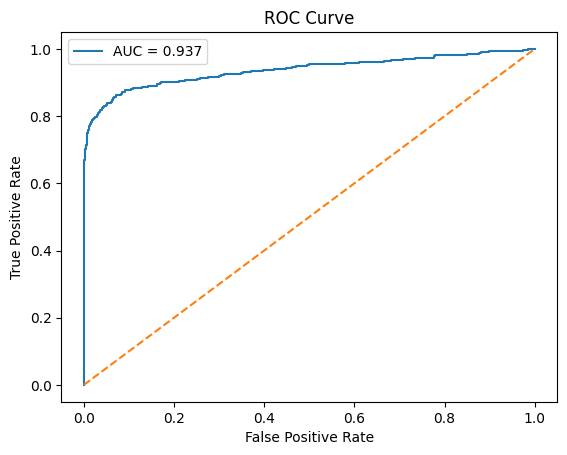

In [2]:
predict_fn = get_predict_fn(cnn_suffix = 'first_time',ae_suffix='first_time')
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = predict_fn(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)

In [2]:
con = duckdb.connect('../capillary.db')
negatives = con.execute(""" 
                 SELECT id FROM protein_data WHERE array_contains(analysis,'0085') AND interpretation ILIKE '%ingen%m%komponent%påvisas%immunfixation%utförd%';
                 """).fetchnumpy()['id']
positives = con.execute(""" 
                 SELECT id FROM protein_data WHERE array_contains(analysis,'0085') AND interpretation ILIKE '%nyupptäckt%m%komponent%';
                 """).fetchnumpy()['id']

df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()
negatives = set(negatives)
positives = set(positives)

df = df[df['id'].isin(negatives | positives)]

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]
df['label'] = df['id'].apply(
    lambda x: 1 if x in positives else 0
)

predict_fn = get_predict_fn(cnn_suffix = 'first_time',ae_suffix='first_time')
test_rows = test_rows[test_rows['label'].isin([0,1])]

result = predict_fn(df)
evaluate(result,threshold=0.5,proportion=70)

              precision    recall  f1-score   support

     Negativ       0.94      0.77      0.85      7362
     Positiv       0.65      0.90      0.76      3474

    accuracy                           0.81     10836
   macro avg       0.80      0.84      0.80     10836
weighted avg       0.85      0.81      0.82     10836

[[5691 1671]
 [ 337 3137]]
Accuracy:  81.47%
FN-rate:   9.70%  (farliga missade fall)
FP-rate:   22.70%  (onödiga larm)
Sensitivitet:   90.30%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   50.00%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)


(array([0.9818671 , 0.38031605, 0.9994518 , ..., 0.25963417, 0.9819756 ,
        0.15651882], shape=(10836,), dtype=float32),
 array([1, 0, 1, ..., 0, 1, 0], shape=(10836,)),
 20        1
 35        0
 67        1
 68        1
 87        1
          ..
 172434    0
 172445    1
 172452    0
 172460    1
 172509    0
 Name: proportion_gamma_region, Length: 10836, dtype: int64,
 array([155130, 170004, 160177, ...,  88747, 152636, 137883],
       shape=(10836,)))